# FRAME — Training Example (Oxygen Isotopes)

This notebook demonstrates training the **Fidelity-Resolved Affine Matrix Emulator (FRAME)** on oxygen isotope data and evaluating predictions with parity plots. FRAME is a global, physics-constrained emulator introduced in *Linking Nuclear Electromagnetic Moments to Nuclear Interactions* (Munoz, Belley, Ekstrom, Hagen, Holt, Garcia Ruiz, 2025).

FRAME maps low-energy constants (LECs) of chiral effective field theory, nuclear identifiers $(Z, N)$, and model-space fidelity $e_\text{max}$ to nuclear energies and electromagnetic observables. It constructs effective Hamiltonians as Hermitian matrices whose entries depend affinely on the LECs, preserving the structure of the chiral interaction. Energies are obtained via spectral decomposition; observables are computed as eigenvector bilinears $\langle v | S | v \rangle$.

**Dataset:** VS-IMSRG + KSHELL calculations for oxygen isotopes O-12 through O-24.  
**Targets:** binding energy (`Energy ket`, MeV) and charge radius (`Rch`, fm).  
**Fidelity levels:** `emax` $\in \{4, 6, 8, 10\}$ (single-particle model-space truncation, $e = 2n + l$).

In [1]:
import sys, os
sys.path.append(os.path.abspath("../frame_public"))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.config import PnBConfig
from src.data_loader import MultiIsotopeDataLoader
from src.model import ParametricMatrixModelPnB
from src.train import Trainer
from src.utils import create_dataloaders, load_object, save_object
from src.inference import InferenceHandler

## 1. Configuration

Set up the model configuration for the oxygen chain ($Z=8$, $A \in [12, 24]$). Each training sample consists of 17 LECs from the non-implausible chiral interaction ensemble, evaluated at one of four model-space fidelities.

Key settings:
- **`target_cols`**: the observables to emulate (binding energy and charge radius)
- **`fidelity_weights`**: upweight higher-fidelity ($e_\text{max}$) data during training, so the emulator prioritizes accuracy where it matters most
- **`epochs`**: 200 is enough for a quick CPU demo; increase to 5000+ for production results (sub-MeV accuracy in $E_b$, sub-0.01 fm in $R_\text{ch}$)

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

config = PnBConfig()

# --- Data ---
config.data_directory = os.path.abspath("../frame_public/data/oxygen")
config.file_pattern = "O*.csv"

# --- Targets ---
config.target_cols = ["Energy ket", "Rch"]
config.output_specs = []          # rebuilt automatically by __post_init__

# On my laptop 5000 epochs takes ~30 mins (fyi)

# --- Training ---
config.device = "cpu"
config.epochs = 4000               # increase to ~10_000+ for production
config.fidelity_weights = {4: 1.0, 6: 1.25, 8: 1.5, 10: 1.75}
config.learning_rate =  0.001 # -> Use a smaller one when you actually do full training

# --- Output directory ---
config.save_dir = os.path.abspath("notebook_results")
config.__post_init__()

print(f"Targets:          {config.target_cols}")
print(f"Output specs:     {config.output_specs}")
print(f"Fidelity weights: {config.fidelity_weights}")
print(f"Device:           {config.device}")
print(f"Epochs:           {config.epochs}")

Targets:          ['Energy ket', 'Rch']
Output specs:     [{'name': 'Energy ket', 'type': 'energy', 'level': 0}, {'name': 'Rch', 'type': 'observable', 'level': 0, 'psd': True}]
Fidelity weights: {4: 1.0, 6: 1.25, 8: 1.5, 10: 1.75}
Device:           cpu
Epochs:           4000


## 2. Load data and build DataLoaders

`MultiIsotopeDataLoader` reads all `O*.csv` files (one per isotope) and extracts $Z$, $N$ from filenames. Each file contains VS-IMSRG calculations across the 17-dimensional LEC space at multiple $e_\text{max}$ levels.

`create_dataloaders` splits into train/val/test, fits standard scalers on the training set, and returns fidelity-bucketed loaders (each batch contains samples from a single $e_\text{max}$ level).

In [3]:
loader = MultiIsotopeDataLoader(config)
combined_df = loader.load_all_data()

train_loader, val_loader, test_loader, fidelity_map, dfs = create_dataloaders(
    combined_df, config, return_dataframes=True
)
train_df, val_df, test_df = dfs

print(f"\nFidelity map: {fidelity_map}")
print(f"Train: {len(train_df)},  Val: {len(val_df)},  Test: {len(test_df)}")

[DataLoader] Found 13 files.
[DataLoader] Combined data shape: (17234, 35)
[Preprocess] Data split => train: 12924, val: 1724, test: 2586
[Preprocess] Shell indicators ready (column 'shell_id').
[Preprocess] Fidelity mapping created: {4: 0, 6: 1, 8: 2, 10: 3}

Fidelity map: {4: 0, 6: 1, 8: 2, 10: 3}
Train: 12924,  Val: 1724,  Test: 2586


## 3. Train

The model consists of two components:
1. **Latent encoder**: embeds $(Z, N, e_\text{max})$ into a continuous representation via sinusoidal/positional encodings and FiLM modulation layers.
2. **Operator core**: builds effective Hamiltonian and observable operators as low-dimensional Hermitian matrices using an anchor-and-refinement strategy with a physics-modulated convergence flow.

The `Trainer` uses a multi-task loss with learned uncertainty weights (splitting energy vs. observable contributions), eigenvector overlap regularization, and early stopping. It automatically restores the best model weights (by validation loss) at the end of training.

In [4]:
model = ParametricMatrixModelPnB(config, list(fidelity_map.keys())).to(config.device)
trainer = Trainer(model, config, fidelity_map)

history = trainer.run_training(train_loader, val_loader)

# Save checkpoint
ckpt_path = os.path.join(config.save_dir, "ckpt_best.pt")
torch.save({"model": model.state_dict()}, ckpt_path)
print(f"\nCheckpoint saved to {ckpt_path}")

[Trainer] Fidelity weights (by ordinal index 0..3) -> tensor([1.0000, 1.2500, 1.5000, 1.7500])


Training:   0%|          | 0/4000 [00:00<?, ?it/s]


Checkpoint saved to /Users/jose/Documents/Works/MIT/WIP/FRAME-public/notebooks/notebook_results/ckpt_best.pt


## 4. Training curves

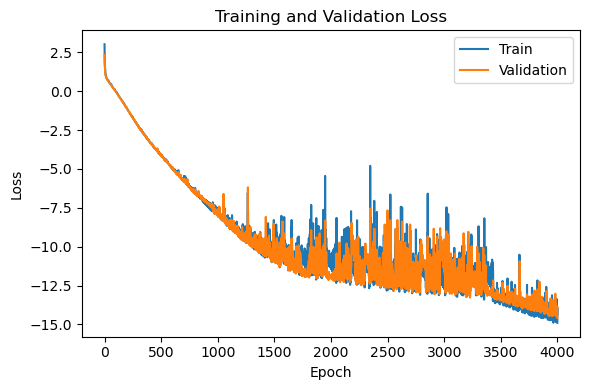

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history["train_loss"], label="Train")
ax.plot(history["valid_loss"], label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Inference on the test set

Load the saved checkpoint via `InferenceHandler`, which handles scaler loading and fidelity mapping automatically. We predict on the highest-fidelity slice ($e_\text{max} = 10$) of the test set, which represents the most expensive *ab initio* calculations and is the regime where emulator accuracy matters most.

In [10]:
inf_handler = InferenceHandler(
    model_path=ckpt_path,
    config=config,
    fidelity_map=fidelity_map,
    device=torch.device("cpu"),
)

# Predict on the highest-fidelity slice of the test set
test_hifi = test_df.query(f"{config.fidelity_col} == {config.max_fid}").reset_index(drop=True)
preds = inf_handler.predict(test_hifi)

print(f"Test samples at emax={config.max_fid}: {len(test_hifi)}")
print(f"Predictions shape: {preds.shape}")

Test samples at emax=10: 172
Predictions shape: (172, 2)


## 6. Parity plots

Compare FRAME predictions against VS-IMSRG ground truth at $e_\text{max} = 10$, colored by isotope (mass number $A = Z + N$). Points on the diagonal $y = x$ line indicate perfect agreement. The absence of systematic clustering by color confirms that the emulator generalizes across the isotopic chain. With full training (5000+ epochs), the emulator achieves sub-MeV accuracy in binding energy and sub-0.01 fm in charge radius (see Supplementary Information of the paper).

/var/folders/zg/s97g7gnj27z83xl9nrhntgxm0000gn/T/ipykernel_53868/3571833922.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("turbo", len(A_unique))


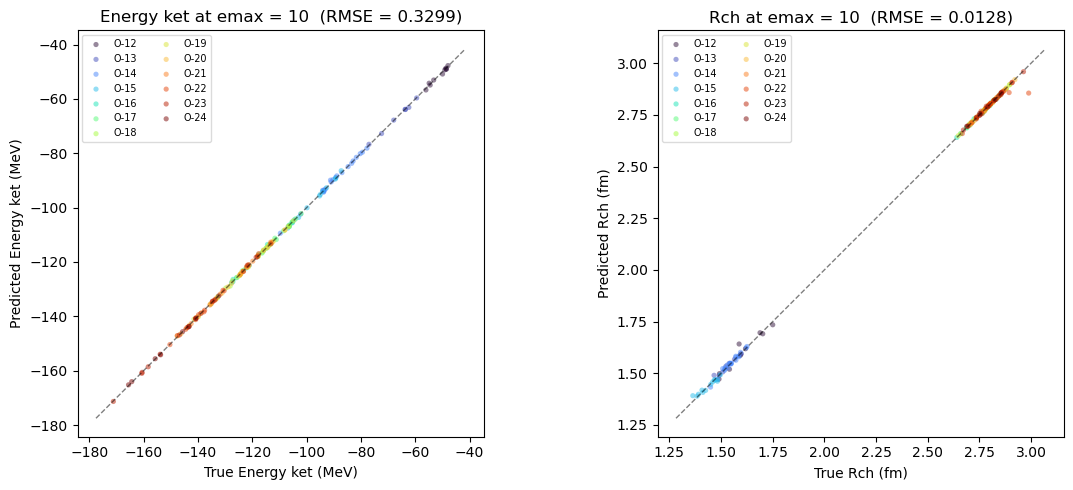

In [11]:
import matplotlib.cm as cm

units = {"Energy ket": "MeV", "Rch": "fm"}
n_targets = len(config.target_cols)

# Mass number for each test sample
A = (test_hifi["Z"] + test_hifi["N"]).to_numpy()
A_unique = np.sort(np.unique(A))

# Colormap: one color per isotope
cmap = cm.get_cmap("turbo", len(A_unique))
color_map = {a: cmap(i) for i, a in enumerate(A_unique)}
colors = [color_map[a] for a in A]

fig, axes = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5))
axes = np.atleast_1d(axes)

for i, col in enumerate(config.target_cols):
    ax = axes[i]
    true = test_hifi[col].to_numpy()
    pred = preds[:, i]
    rmse = float(np.sqrt(np.mean((true - pred) ** 2)))

    # Scatter colored by isotope
    for a_val in A_unique:
        mask = A == a_val
        ax.scatter(true[mask], pred[mask], c=[color_map[a_val]], alpha=0.5,
                   s=14, label=f"O-{a_val}", edgecolors="none")

    # Diagonal
    lo = min(true.min(), pred.min())
    hi = max(true.max(), pred.max())
    margin = 0.05 * (hi - lo)
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            "k--", alpha=0.5, linewidth=1)

    unit = units.get(col, "")
    ax.set_xlabel(f"True {col} ({unit})")
    ax.set_ylabel(f"Predicted {col} ({unit})")
    ax.set_title(f"{col} at emax = {config.max_fid}  (RMSE = {rmse:.4f})")
    ax.legend(fontsize=7, ncol=2, loc="upper left", framealpha=0.7)
    ax.set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()

## 7. Convergence flow and extrapolation to unseen fidelity

A key feature of FRAME is its physics-modulated convergence flow: predictions at successive $e_\text{max}$ levels are generated by a continuous coordinate $\xi(f) = \sigma(\mathbf{h}, \boldsymbol{\alpha}) \cdot (1/f_\text{min} - 1/f)$, which smoothly interpolates and extrapolates the effective Hamiltonian across model-space truncations. This means we can evaluate the trained model at $e_\text{max} = 12$, a fidelity level **never seen during training**, to obtain a controlled extrapolation toward the converged result.

Below we pick a few LEC samples for selected isotopes, sweep the model across $e_\text{max} \in \{4, 6, 8, 10, 12\}$, and plot the predicted convergence trajectory. The ground truth (VS-IMSRG) at $e_\text{max} = 10$ is shown as filled markers for reference.

/var/folders/zg/s97g7gnj27z83xl9nrhntgxm0000gn/T/ipykernel_53868/3620656807.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(isotopes_to_show))


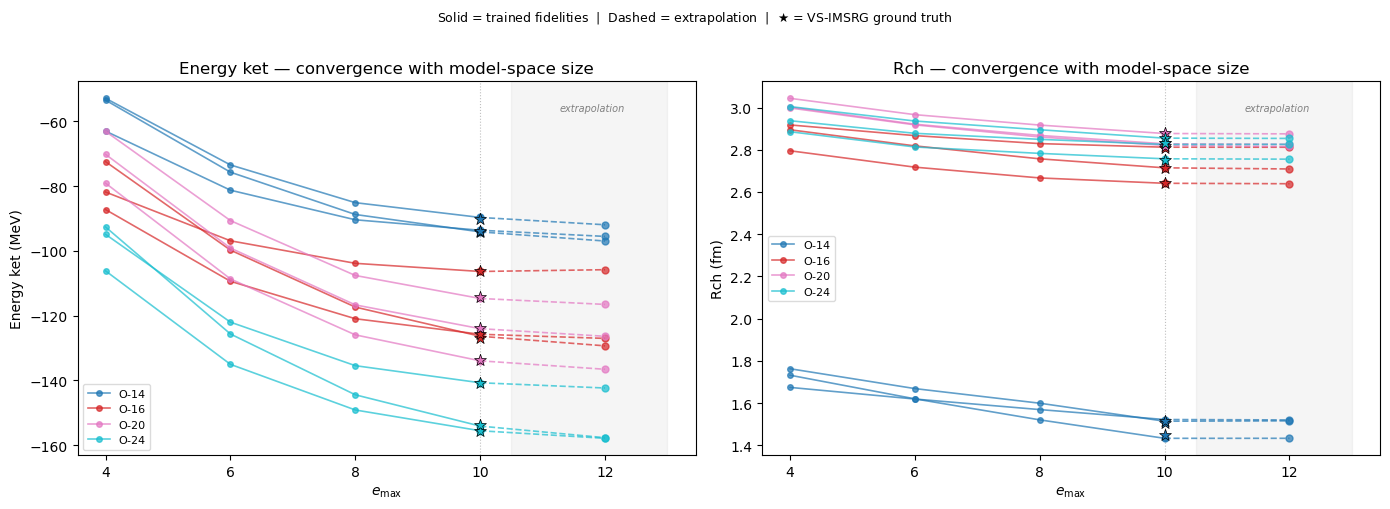

In [12]:
isotopes_to_show = [14, 16, 20, 24]   # mass numbers A
n_samples_per_iso = 3
emax_train = [4, 6, 8, 10]
emax_all = [4, 6, 8, 10, 12]          # 12 is extrapolation

# --- Build a sweep DataFrame: same LEC samples evaluated at every emax ---
sweep_rows = []
sweep_meta = []   # (A, sample_idx, emax)

for A_val in isotopes_to_show:
    iso_df = test_hifi[(test_hifi["Z"] + test_hifi["N"]) == A_val]
    if len(iso_df) == 0:
        continue
    selected = iso_df.sample(n=min(n_samples_per_iso, len(iso_df)), random_state=42)
    for s_idx, (_, row) in enumerate(selected.iterrows()):
        for emax in emax_all:
            new_row = row.copy()
            new_row[config.fidelity_col] = emax
            sweep_rows.append(new_row)
            sweep_meta.append((A_val, s_idx, emax))

sweep_df = pd.DataFrame(sweep_rows).reset_index(drop=True)
meta_df = pd.DataFrame(sweep_meta, columns=["A", "sample_idx", "emax"])

# --- Run inference ---
sweep_preds = inf_handler.predict(sweep_df)

# --- Collect ground truth at emax=10 ---
gt_at_10 = {}
for A_val in isotopes_to_show:
    iso_df = test_hifi[(test_hifi["Z"] + test_hifi["N"]) == A_val]
    selected = iso_df.sample(n=min(n_samples_per_iso, len(iso_df)), random_state=42)
    for s_idx, (_, row) in enumerate(selected.iterrows()):
        for i, col in enumerate(config.target_cols):
            gt_at_10[(A_val, s_idx, i)] = row[col]

# --- Plot ---
units = {"Energy ket": "MeV", "Rch": "fm"}
n_targets = len(config.target_cols)
cmap = cm.get_cmap("tab10", len(isotopes_to_show))
iso_colors = {A_val: cmap(j) for j, A_val in enumerate(isotopes_to_show)}

fig, axes = plt.subplots(1, n_targets, figsize=(7 * n_targets, 5))
axes = np.atleast_1d(axes)

for i, col in enumerate(config.target_cols):
    ax = axes[i]

    # Extrapolation shading
    ax.axvspan(10.5, 13, color="gray", alpha=0.08)
    ax.axvline(10, color="gray", ls=":", lw=0.8, alpha=0.5)

    legend_done = set()

    for A_val in isotopes_to_show:
        for s_idx in range(n_samples_per_iso):
            mask = (meta_df["A"] == A_val) & (meta_df["sample_idx"] == s_idx)
            if mask.sum() == 0:
                continue

            emax_vals = meta_df.loc[mask, "emax"].to_numpy()
            pred_vals = sweep_preds[mask.to_numpy(), i]

            label = f"O-{A_val}" if A_val not in legend_done else None
            legend_done.add(A_val)

            # Training region (solid)
            train_mask = emax_vals <= 10
            ax.plot(emax_vals[train_mask], pred_vals[train_mask], "-o",
                    color=iso_colors[A_val], ms=4, lw=1.2, alpha=0.7, label=label)

            # Extrapolation (dashed)
            extrap_mask = emax_vals >= 10
            ax.plot(emax_vals[extrap_mask], pred_vals[extrap_mask], "--o",
                    color=iso_colors[A_val], ms=5, lw=1.2, alpha=0.7)

            # Ground truth at emax=10
            gt = gt_at_10.get((A_val, s_idx, i))
            if gt is not None:
                ax.scatter([10], [gt], marker="*", s=80, color=iso_colors[A_val],
                           edgecolors="k", linewidths=0.5, zorder=5)

    unit = units.get(col, "")
    ax.set_xlabel("$e_{\\mathrm{max}}$")
    ax.set_ylabel(f"{col} ({unit})")
    ax.set_xticks(emax_all)
    ax.set_title(f"{col} — convergence with model-space size")
    ax.legend(fontsize=8, loc="best", framealpha=0.7)

    # Add annotation for extrapolation region
    ax.text(11.8, ax.get_ylim()[0] + 0.92 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "extrapolation", fontsize=7, ha="center", color="gray", style="italic")

fig.suptitle("Solid = trained fidelities  |  Dashed = extrapolation  |  $\\bigstar$ = VS-IMSRG ground truth",
             fontsize=9, y=1.01)
fig.tight_layout()
plt.show()